In [1]:
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import seaborn as sns
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from emle.models import EMLE
from emle.train import EMLETrainer
from emle.train._utils import pad_to_max

warnings.filterwarnings("ignore")

color_by_z = {1: "grey", 6: "cyan", 7: "blue", 8: "red", 16: "yellow"}
ANGSTROM_TO_BOHR =1.8897259886 

/home/joaomorado/micromamba/envs/fes-ml-aev/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

### Load Data

In [3]:
xdm_data = h5py.File(
    "pyxdm.output.h5", "r"
)
# Load exchange-hole moments
m1 = xdm_data["summary_moments"][:, :, 0]
m2 = xdm_data["summary_moments"][:, :, 1]
m3 = xdm_data["summary_moments"][:, :, 2]

m1_ds = pad_to_max(m1).to(device=device, dtype=dtype)
m2_ds = pad_to_max(m2).to(device=device, dtype=dtype)
m3_ds = pad_to_max(m3).to(device=device, dtype=dtype)

# Load atomic data
xyz = xdm_data["atoms"][:, :, 1:4] / ANGSTROM_TO_BOHR
species = xdm_data["atoms"][:, :, 0]

# Pad to max number of atoms
xyz_ds = pad_to_max(xyz).to(device=device, dtype=dtype)
species_ds = pad_to_max(species).to(device=device, dtype=torch.long)
dummy_s = torch.zeros(xyz_ds.shape[0], xyz_ds.shape[1], 1).to(
    device=device, dtype=dtype
)
q_mol = torch.zeros(xyz_ds.shape[0]).to(device=device, dtype=dtype)

### Generate effective exchange-hole dipole moments

In [4]:
def c6(alpha, m1):
    """XDM C6 coefficient calculation for homoatomic case."""
    return alpha * m1 / 2.0


def c8(alpha, m2):
    """XDM C8 coefficient calculation for homoatomic case."""
    return alpha * m2 * 3 / 2.0


def c10(alpha, m1, m2, m3):
    """XDM C10 coefficient calculation for homoatomic case."""
    return 2.0 * alpha * m3 + 21 / 10 * alpha * m2**2 / (m1 + 1e-16)


def r_vdw(c6, c8, c10, a1=1.0, a2=0.0):
    """https://doi.org/10.1063/5.0207682"""
    r_crit = (1 / 3.0) * ((c8 / c6) ** 0.5 + (c10 / c6) ** 0.25 + (c10 / c8) ** 0.5)
    return a1 * r_crit + a2

In [5]:
emle = EMLE(
    model="../../emle_models/ligand_patched_reference_iter2.mat",
    alpha_mode="reference",
    device=device,
)
emle_base = emle._emle_base
s, q_core, q_val, A_thole, _ = emle_base(species_ds, xyz_ds, q_mol)
alpha = emle_base.get_isotropic_polarizabilities(A_thole)
alpha = alpha.detach() * (species_ds > 0)
rmin2 = 2.54 * alpha ** (1 / 7) * 2

In [6]:
# Calculate dispersion coefficients
c6_train = c6(alpha, m1_ds)
c8_train = c8(alpha, m2_ds)
c10_train = c10(alpha, m1_ds, m2_ds, m3_ds)
r_vdw_train = r_vdw(c6_train, c8_train, c10_train)

# Setup grid
n = 1000
rij_scale = torch.linspace(1.0, 3.0, n).to(device=device)
rmin_expanded = rmin2.unsqueeze(-1)
rij = rmin_expanded * rij_scale

# Calculate damped dispersion energy
Eij = -(
    c6_train[..., None] / (rij**6 + r_vdw_train[..., None] ** 6)
    + c8_train[..., None] / (rij**8 + r_vdw_train[..., None] ** 8)
    + c10_train[..., None] / (rij**10 + r_vdw_train[..., None] ** 10)
)

In [7]:
# Setup optimization
lr = 0.1
m1_eff = torch.nn.Parameter(m1_ds.clone().detach())
optimizer = torch.optim.Adam([m1_eff], lr=lr)

# Perform optimization
n_epochs = 500
mask = species_ds > 0
for epoch in range(n_epochs):
    optimizer.zero_grad()
    c6_opt = c6(alpha, m1_eff)
    Eij_opt = -c6_opt[..., None] / (rij**6 + 1e-16)
    loss = torch.mean((Eij_opt[mask] - Eij[mask]) ** 2) / torch.var(Eij[mask])
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.17890149354934692
Epoch 100, Loss: 0.0022557454649358988
Epoch 200, Loss: 0.0021078628487885
Epoch 300, Loss: 0.0021078609861433506
Epoch 400, Loss: 0.0021078609861433506


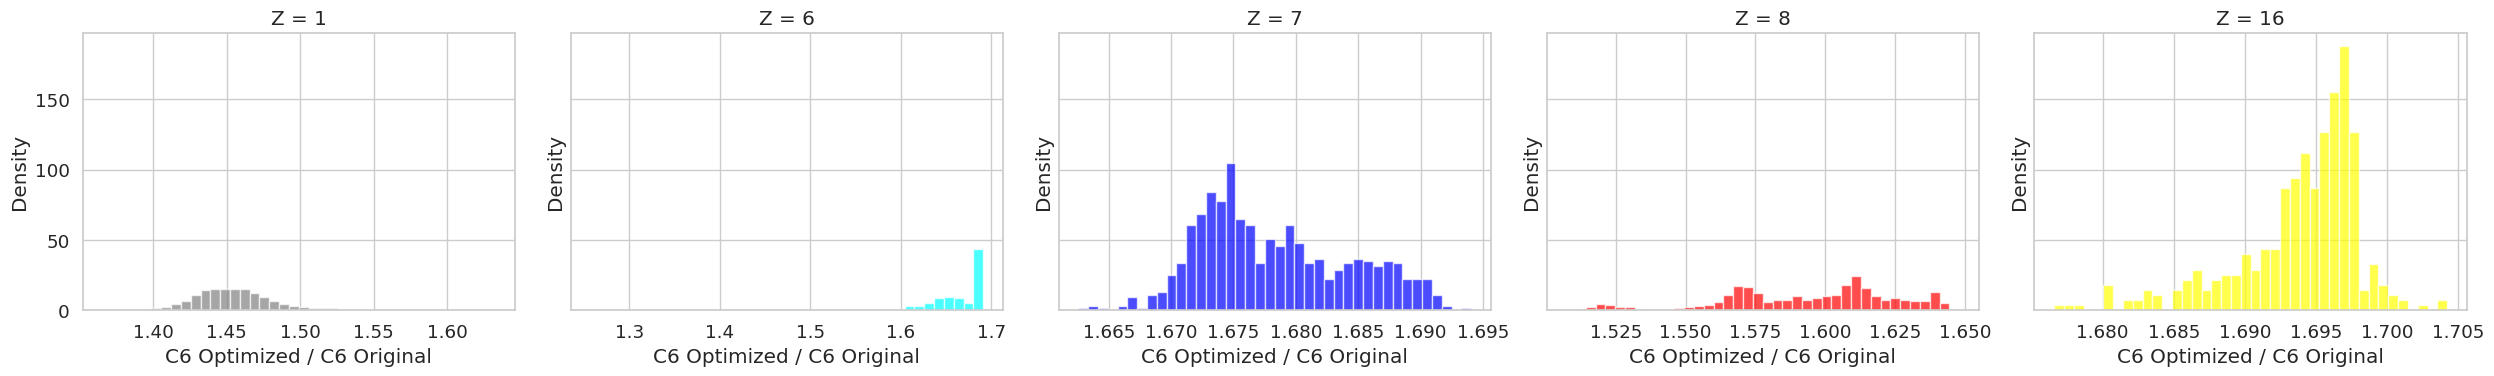

In [8]:
# Compute ratios
c6_optimized = c6(alpha, m1_eff).detach().cpu().numpy().flatten()
c6_orig = c6_train.cpu().numpy().flatten()
ratios = c6_optimized / c6_orig
species_np = species_ds.cpu().numpy().flatten()

sns.set(style="whitegrid", font_scale=1.2)

# Create one subplot per Z
z_values = sorted(color_by_z.keys())
fig, axes = plt.subplots(1, len(z_values), figsize=(5 * len(z_values), 4), sharey=True)

# If only one Z, axes may not be iterable
if len(z_values) == 1:
    axes = [axes]

for ax, z in zip(axes, z_values):
    mask = species_np == z
    ax.hist(
        ratios[mask],
        bins=40,
        alpha=0.7,
        color=color_by_z[z],
        density=True,
    )
    ax.set_title(f"Z = {z}")
    ax.set_xlabel("C6 Optimized / C6 Original")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


### Create training dataset

In [9]:
perm = torch.randperm(xyz_ds.shape[0])
n_samples = len(perm)
n_train = int(0.8 * n_samples)
train_idx = perm[:n_train]
val_idx = perm[n_train:]

def split_tensor(t, idx_train, idx_val):
    return t[idx_train], t[idx_val]

xyz_train, xyz_val = split_tensor(xyz_ds, train_idx, val_idx)
species_train, species_val = split_tensor(species_ds, train_idx, val_idx)
m1_train, m1_val = split_tensor(m1_eff.detach(), train_idx, val_idx)
dummy_s_train, dummy_s_val = split_tensor(dummy_s, train_idx, val_idx)

### Train <M1> coefficients

In [10]:
plot_data_filename = "c6_training_data_results.mat"
trainer = EMLETrainer()
trainer.train(
    z=species_train,
    xyz=xyz_train,
    s=dummy_s_train,
    c6=m1_train,
    q_mol=torch.zeros(xyz_train.shape[0]),
    lr_c6=1e-2,
    epochs=1500,
    emle_model="../../emle_models/ligand_patched_reference_iter2.mat",
    plot_data_filename=plot_data_filename,
    model_filename="ligand_patched_reference_iter2_c6.mat",
    l2_reg_c6=1e-3,
)

2025-11-27 20:26:04.789 | INFO     | emle.train._trainer:train:625 - Loading pre-trained EMLE model from '../../emle_models/ligand_patched_reference_iter2.mat'
2025-11-27 20:26:04.806 | INFO     | emle.train._trainer:train:695 - Fitting c6 values...
2025-11-27 20:26:05.938 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 10: Loss =  23.0460    RMSE =   4.8006    Max Error =  18.3437
2025-11-27 20:26:06.962 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 20: Loss =  20.1481    RMSE =   4.4887    Max Error =  18.3657
2025-11-27 20:26:07.976 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 30: Loss =  16.8554    RMSE =   4.1055    Max Error =  18.5140
2025-11-27 20:26:08.989 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 40: Loss =  13.3889    RMSE =   3.6591    Max Error =  18.6726
2025-11-27 20:26:09.999 | INFO     | emle.train._trainer:_train_loop:278 - Epoch 50: Loss =  10.1308    RMSE =   3.1829    Max Error =  18.8288
2025-11-27 20:26:11.006 | INFO

EMLEBase(
  (_emle_aev_computer): EMLEAEVComputer(
    (_aev_computer): AEVComputer()
  )
)

### Plot results for training dataset

In [11]:
# Get training results
training_results = scipy.io.loadmat(plot_data_filename)

# Get testing results
emle = EMLE(model="ligand_patched_reference_iter2_c6.mat", dispersion_mode="c6", device=device)
emle_base = emle._emle_base
*_, c6_pred_val = emle_base.forward(
    species_val,
    xyz_val.to(torch.float32),
    torch.zeros(xyz_val.shape[0], device=device),
    calc_c6=True,
)

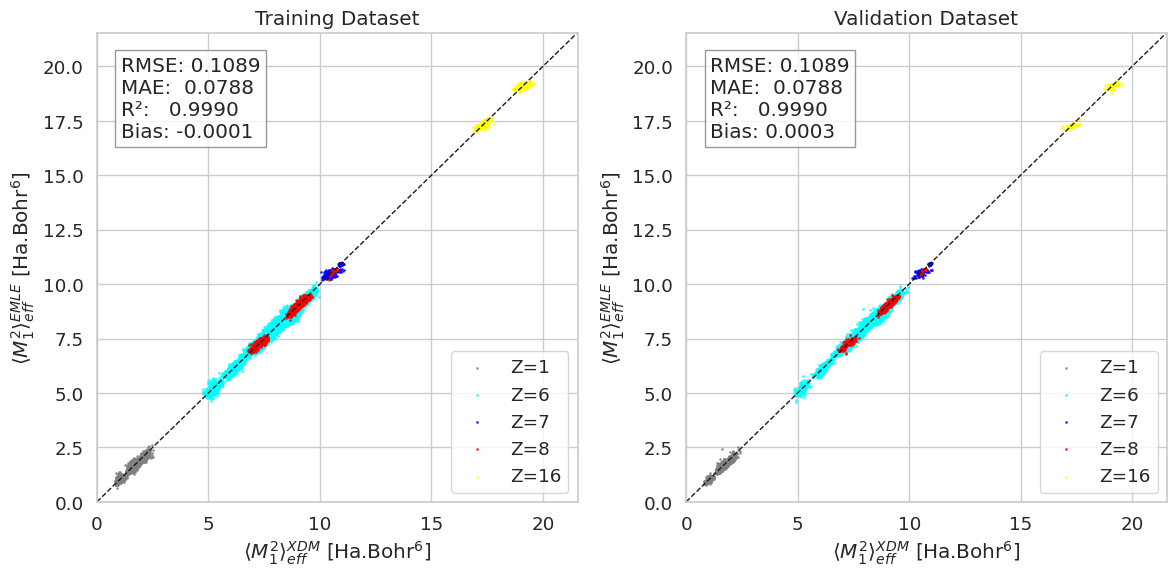

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set(style="whitegrid", font_scale=1.2)
xlabel = r"$\langle M_1^2 \rangle_{eff}^{XDM}$ [Ha.Bohr$^6$]"
ylabel = r"$\langle M_1^2 \rangle_{eff}^{EMLE}$ [Ha.Bohr$^6$]"

datasets = [
    {
        "ax": axes[0],
        "y_true": training_results["c6_qm"],
        "y_pred": training_results["c6_emle"],
        "species": species_train.cpu().numpy(),
        "title": "Training Dataset",
    },
    {
        "ax": axes[1],
        "y_true": m1_val.cpu().detach().numpy(),
        "y_pred": c6_pred_val.cpu().detach().numpy(),
        "species": species_val.cpu().numpy(),
        "title": "Validation Dataset",
    },
]

for data in datasets:
    ax = data["ax"]
    species = data["species"]
    y_true = data["y_true"]
    y_pred = data["y_pred"]

    # Calculate error and correlation metrics
    mask_global = y_true > 0
    rmse = np.sqrt(mean_squared_error(y_true[mask_global], y_pred[mask_global]))
    mae = mean_absolute_error(y_true[mask_global], y_pred[mask_global])
    r2 = r2_score(y_true[mask_global], y_pred[mask_global])
    bias = np.mean(y_pred[mask_global] - y_true[mask_global])

    for z in color_by_z.keys():
        mask = (species == z) & (y_true > 0)
        ax.scatter(
            y_true[mask],
            y_pred[mask],
            alpha=0.7,
            s=1,
            color=color_by_z[z],
            label=f"Z={z}",
        )

    lims = [0, training_results["c6_qm"].max() * 1.1]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(data["title"])

    text_metrics = (
        f"RMSE: {rmse:.4f}\nMAE:  {mae:.4f}\nR²:   {r2:.4f}\nBias: {bias:.4f}"
    )
    ax.text(
        0.05,
        0.95,
        text_metrics,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )

    ax.legend()

plt.tight_layout()
plt.show()